Step1: Importing Necessay Libraries

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Step2: Loading Dataset

In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:
df= pd.read_csv("/content/diabetes - diabetes.csv")

In [113]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [115]:
df.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [116]:
df.shape

(768, 9)

Step3: Handling missing value

In [117]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [118]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].mean())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [119]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [120]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.710121,70.935397,27.768651,142.210761,30.888434,0.429734,31.190000
1,4.865672,142.165573,75.147324,31.736944,180.431548,35.384757,0.550500,37.067164


Step4: Splitting the data into training data and testing data

In [121]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X.shape,X_train.shape,X_test.shape)
print(X)
print(y)

(768, 8) (614, 8) (154, 8)
     Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0              6    148.0           72.0       35.00000  155.548223  33.6   
1              1     85.0           66.0       29.00000  155.548223  26.6   
2              8    183.0           64.0       29.15342  155.548223  23.3   
3              1     89.0           66.0       23.00000   94.000000  28.1   
4              0    137.0           40.0       35.00000  168.000000  43.1   
..           ...      ...            ...            ...         ...   ...   
763           10    101.0           76.0       48.00000  180.000000  32.9   
764            2    122.0           70.0       27.00000  155.548223  36.8   
765            5    121.0           72.0       23.00000  112.000000  26.2   
766            1    126.0           60.0       29.15342  155.548223  30.1   
767            1     93.0           70.0       31.00000  155.548223  30.4   

     DiabetesPedigreeFunction  Age  
0          

Step5: Feature Scaling

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train)
print(X_test)

[[-0.52639686 -1.25828206  0.01321033 ...  0.01501323 -0.49073479
  -1.03594038]
 [ 1.58804586 -0.32735374  0.8068672  ... -0.59935041  2.41502991
   1.48710085]
 [-0.82846011  0.57032714 -2.17095414 ... -0.52719904  0.54916055
  -0.94893896]
 ...
 [ 1.8901091  -0.69307558  1.13773624 ...  1.91151712  1.981245
   0.44308379]
 [-1.13052335  0.63682202  0.01321033 ...  1.44974838 -0.78487662
  -0.33992901]
 [-1.13052335  0.10486298  1.96490883 ... -1.42187598 -0.61552223
  -1.03594038]]
[[ 0.68185612 -0.7928179  -1.17834702 ...  0.23760544 -0.11637247
   0.87809089]
 [-0.52639686 -0.32735374  0.22784639 ...  0.48292008 -0.954231
  -1.03594038]
 [-0.52639686 -0.4603435  -0.68204347 ... -0.22416331 -0.9245197
  -1.03594038]
 ...
 [ 1.28598261 -0.89256022 -0.02030539 ...  0.64165309  0.04703966
   2.0961108 ]
 [-0.52639686  0.80305922 -0.18573991 ... -0.62821095 -0.39268751
  -0.33992901]
 [ 1.28598261 -1.59075646 -0.18573991 ...  0.42519899  0.70068816
   0.53008521]]


Step6: Training Model

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Creating model
classifier = LogisticRegression(random_state=0)

# Training model
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [124]:
# Prediction on training data
X_train_prediction = classifier.predict(X_train)

# Training accuracy
training_data_accuracy = accuracy_score(
    X_train_prediction,
    y_train
)

print('Accuracy on training data:',
      training_data_accuracy *100)


# Prediction on test data
X_test_prediction = classifier.predict(X_test)

# Test accuracy
test_data_accuracy = accuracy_score(
    X_test_prediction,
    y_test
)

print('Accuracy on test data:',
      test_data_accuracy*100)


Accuracy on training data: 77.19869706840392
Accuracy on test data: 75.32467532467533


In [125]:
# Making Confusion Matrix and calculating accuracy score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

model = LogisticRegression()

#Fit the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mylist = []
# Confusion Matrix
conf_matrix= confusion_matrix(y_test, y_pred)
# accuracy score
acc_logreg = accuracy_score(y_test, y_pred)
print('Confusion Matrix for Logistic Regression:')
print(conf_matrix)
print('Accuracy of Logistic Regression:',acc_logreg)
mylist.append(acc_logreg)

Confusion Matrix for Logistic Regression:
[[82 17]
 [21 34]]
Accuracy of Logistic Regression: 0.7532467532467533


Step7: Data visualization

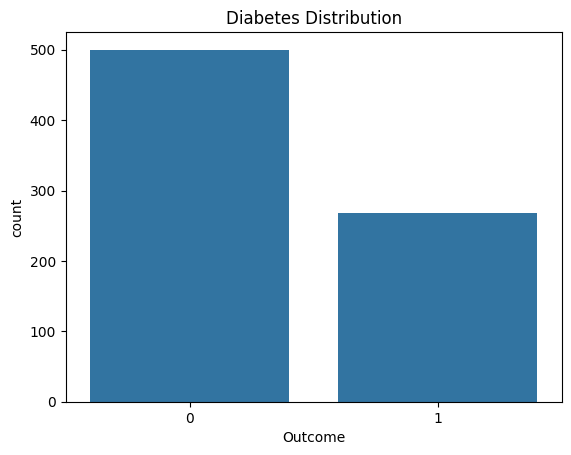

In [126]:
#Count Plot (Diabetes Distribution)
sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Distribution")

plt.show()

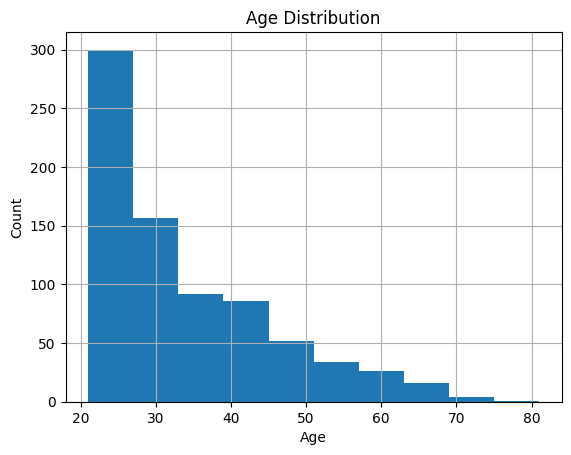

In [127]:
#Histogram
df['Age'].hist(bins=10)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

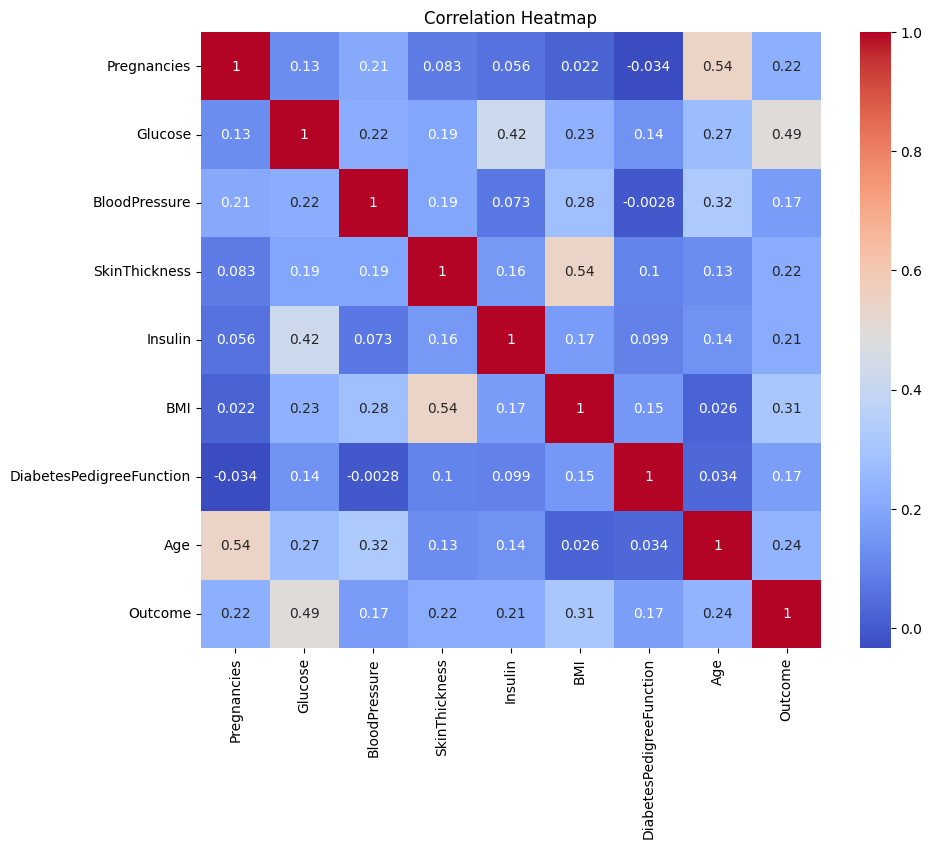

In [128]:
#Correlation Heatmap
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()


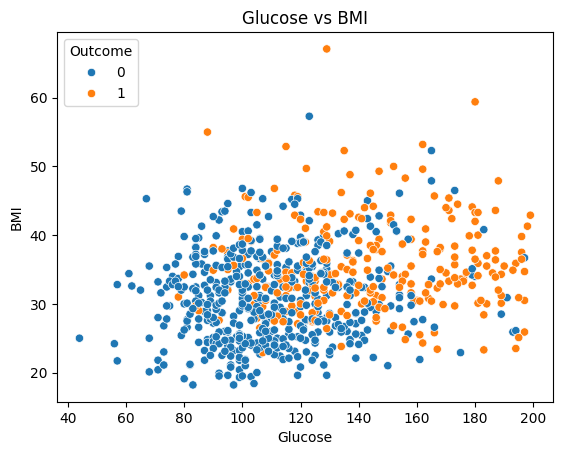

In [129]:
#Scatter Plot
sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.title("Glucose vs BMI")

plt.show()

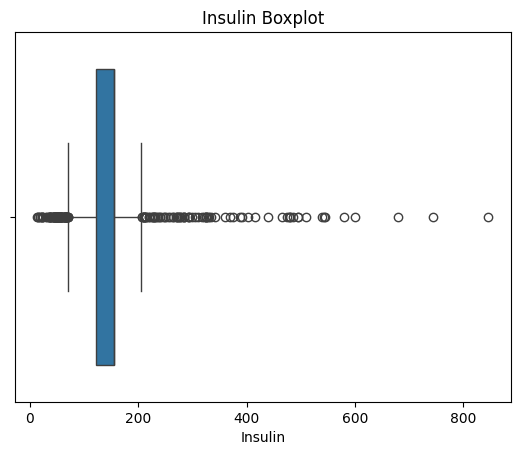

In [130]:
#Box Plot
sns.boxplot(x=df['Insulin'])

plt.title("Insulin Boxplot")

plt.show()

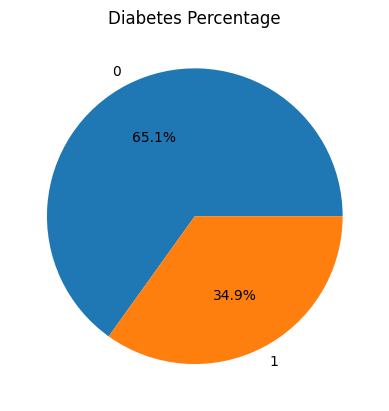

In [131]:
#Pie Chart
df['Outcome'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Diabetes Percentage")

plt.ylabel("")

plt.show()

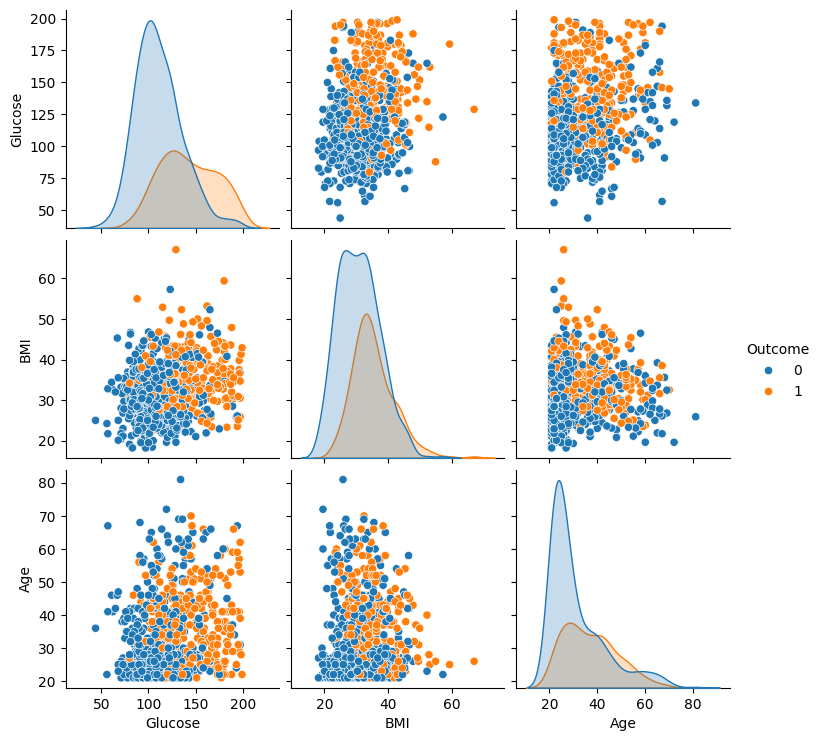

In [132]:
#Pair Plot
sns.pairplot(
    df[['Glucose','BMI','Age','Outcome']],
    hue='Outcome'
)

plt.show()

Step8: Building a predictive model

In [133]:
import numpy as np
import pandas as pd

# Taking input from user

Pregnancies = int(input("Enter Pregnancies: "))
Glucose = float(input("Enter Glucose Level: "))
BloodPressure = float(input("Enter Blood Pressure: "))
SkinThickness = float(input("Enter Skin Thickness: "))
Insulin = float(input("Enter Insulin Level: "))
BMI = float(input("Enter BMI Value: "))
DiabetesPedigreeFunction = float(input("Enter Diabetes Pedigree Function: "))
Age = int(input("Enter Age: "))

# Create dataframe with column names

input_data = pd.DataFrame([[
    Pregnancies,
    Glucose,
    BloodPressure,
    SkinThickness,
    Insulin,
    BMI,
    DiabetesPedigreeFunction,
    Age
]], columns=[
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
])

# Standardize input data

std_data = scaler.transform(input_data)

# Prediction

prediction = classifier.predict(std_data)

# Output result

if prediction[0] == 0:
    print("\nThe person does NOT have diabetes")
else:
    print("\nThe person HAS diabetes")

Enter Pregnancies: 2
Enter Glucose Level: 120
Enter Blood Pressure: 70
Enter Skin Thickness: 30
Enter Insulin Level: 85
Enter BMI Value: 89
Enter Diabetes Pedigree Function: 0.5
Enter Age: 25

The person HAS diabetes
